# 📘 Activity 04: Linear Regression with scikit-learn + K-Fold Cross-Validation

**Track:** Linear Regression  
**Level:** Intermediate  
**K-Fold:** ✅ Core Focus

---

## 📖 What You Will Learn
- Build a linear regression model with sklearn
- Understand the mathematics behind OLS (Ordinary Least Squares)
- **K-Fold Cross-Validation** — why it beats a single train/test split
- Bias-Variance Tradeoff
- Evaluation metrics: MSE, RMSE, MAE, R²
- Visualise residuals and prediction quality

---

## 🧠 Concept: Linear Regression

Linear regression fits the model:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_p x_p$$

The **Ordinary Least Squares (OLS)** solution minimises the sum of squared residuals:

$$\min_{\beta} \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

Closed-form solution: $\hat{\beta} = (X^T X)^{-1} X^T y$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score, cross_validate
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings; warnings.filterwarnings('ignore')
np.random.seed(42)
print('✅ Ready')

✅ Ready


## 📊 Load Data

In [2]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

print(f'Dataset: {X.shape[0]} samples, {X.shape[1]} features')
print(f'Target range: [{y.min():.2f}, {y.max():.2f}]')
print()
print(df.describe().round(2))

Dataset: 20640 samples, 8 features
Target range: [0.15, 5.00]

         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude  MedHouseVal  
count  20640.00   20640.00     20640.00  
mean      35.63    -119.57         2.07  
std        2.14       2.00         1.15  
min       32.54    -124.35         0.15  
25%       33.93    -121.80         1.20  
50%       34.26    -118.49         1

## 🔍 Step 1 — Exploratory Data Analysis

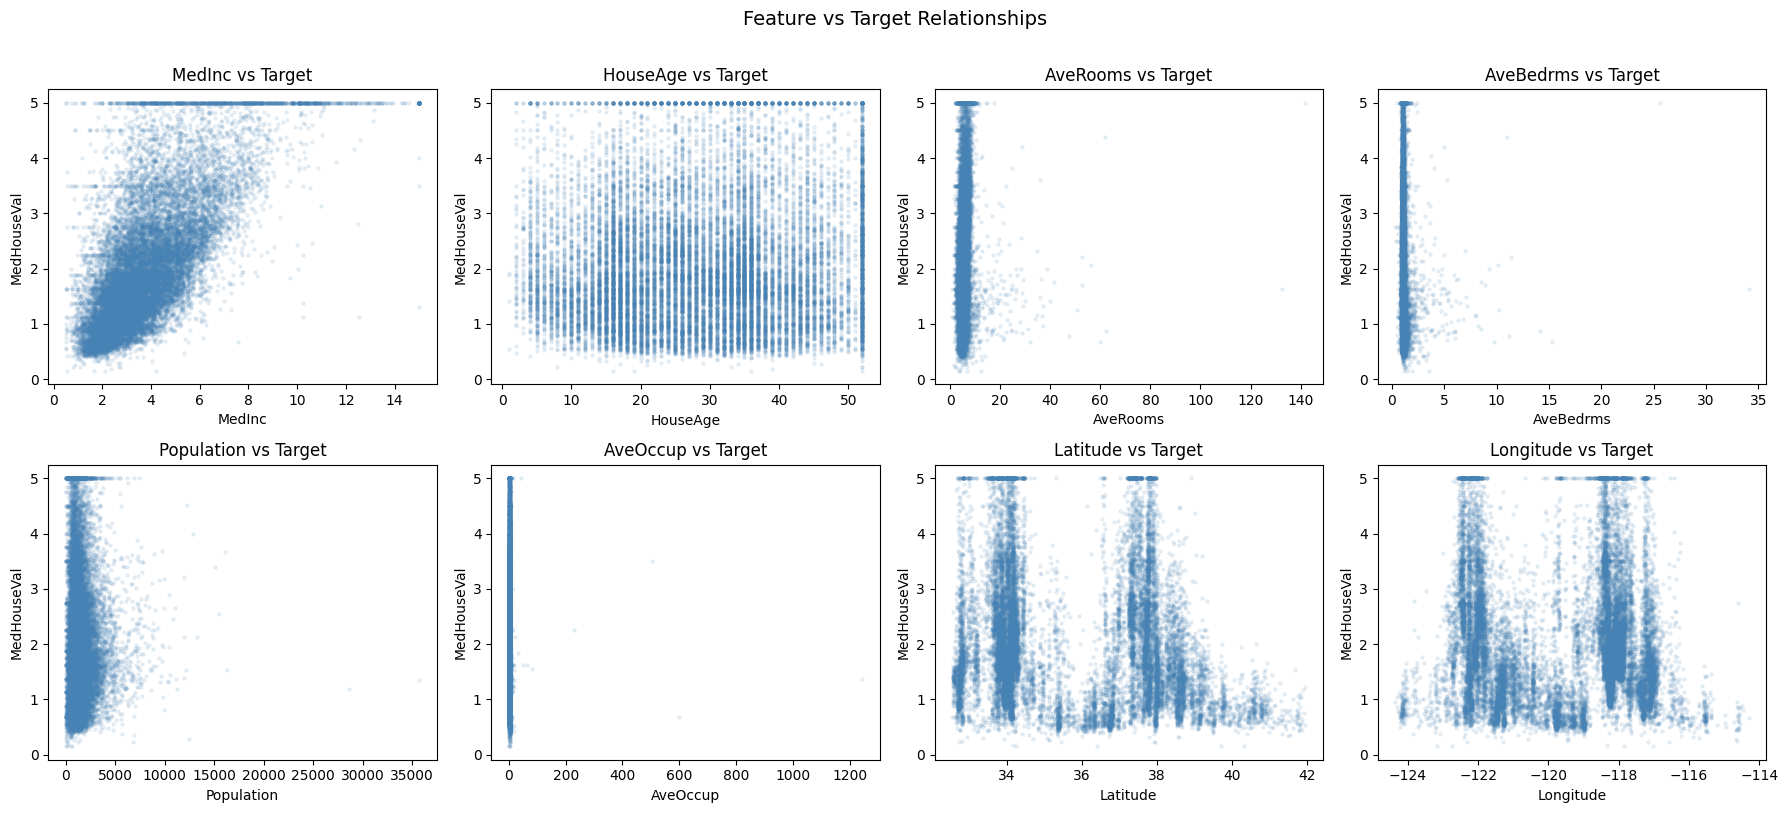

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for i, col in enumerate(X.columns):
    axes[i].scatter(X[col], y, alpha=0.1, s=5, color='steelblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('MedHouseVal')
    axes[i].set_title(f'{col} vs Target')

plt.suptitle('Feature vs Target Relationships', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

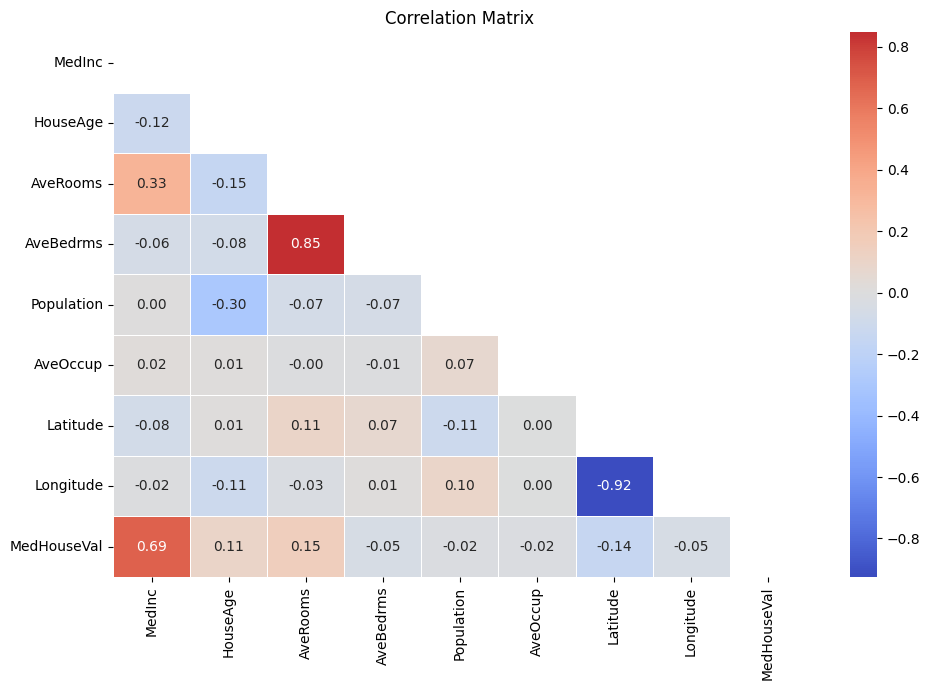

In [4]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 🔧 Step 2 — Single Train/Test Split (Baseline)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LinearRegression()),
])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

metrics_single = {
    'R²':   r2_score(y_test, y_pred),
    'MAE':  mean_absolute_error(y_test, y_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
}

print('=== Single Train/Test Split ===')
for k, v in metrics_single.items():
    print(f'  {k:<6}: {v:.4f}')

=== Single Train/Test Split ===
  R²    : 0.5758
  MAE   : 0.5332
  RMSE  : 0.7456


## 🔄 Step 3 — K-Fold Cross Validation

### 🧠 Concept: Why K-Fold is Better

With a single split:
- Performance **depends on the random seed** used to split
- You might happen to have an easy test set → overestimates performance
- You leave training data unused for evaluation

With K-Fold:
- Every sample is used **once as test data** and K-1 times for training
- You get **K performance estimates** → mean ± std
- Much more **statistically reliable** estimate of true generalisation performance

```
K=5 example, 100 samples:

Fold 1: [TEST | train | train | train | train]
Fold 2: [train | TEST | train | train | train]
Fold 3: [train | train | TEST | train | train]
Fold 4: [train | train | train | TEST | train]
Fold 5: [train | train | train | train | TEST]
```

### 🧠 When NOT to use K-Fold:
- **Time series data** — future data must not appear in training → use `TimeSeriesSplit`
- **Very large datasets (millions of rows)** — K-Fold adds K× training cost; a single holdout may suffice
- **Grouped data** — patients, users → use `GroupKFold`

### ⚠️ Data Leakage Risk with K-Fold:
If any preprocessing (scaling, imputation) is applied BEFORE K-Fold, statistics from test folds leak into training folds.  
**Solution:** Always wrap preprocessing in a `Pipeline` — sklearn automatically fits transformers only on training folds.

In [7]:
# ── K-Fold Cross-Validation ────────────────────────────────────────────────────
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# cross_validate returns train + test scores
cv_results = cross_validate(
    pipe,
    X, y,
    cv=kf,
    scoring=['r2', 'neg_mean_absolute_error', 'neg_root_mean_squared_error'],
    return_train_score=True,
)

print('=== 5-Fold Cross-Validation Results ===')
print(f"  Train R² : {cv_results['train_r2'].mean():.4f} ± {cv_results['train_r2'].std():.4f}")
print(f"  Test  R² : {cv_results['test_r2'].mean():.4f}  ± {cv_results['test_r2'].std():.4f}")
print(f"  Test MAE : {-cv_results['test_neg_mean_absolute_error'].mean():.4f}")
print(f"  Test RMSE: {-cv_results['test_neg_root_mean_squared_error'].mean():.4f}")

=== 5-Fold Cross-Validation Results ===
  Train R² : 0.6065 ± 0.0045
  Test  R² : 0.6014  ± 0.0170
  Test MAE : 0.5317
  Test RMSE: 0.7283


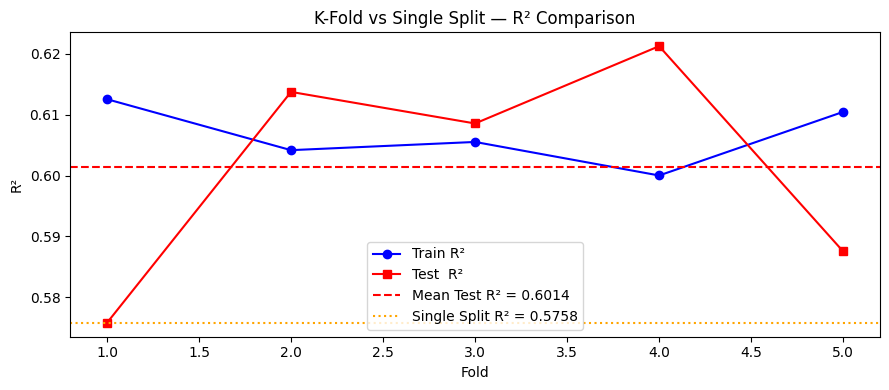


📊 Insight: The spread of fold R² values shows the variance in model performance.
   A large spread → the model is sensitive to which data it trains on (high variance).


In [8]:
# ── Visualise K-Fold fold-by-fold performance ─────────────────────────────────
fold_r2_train = cv_results['train_r2']
fold_r2_test  = cv_results['test_r2']
folds = range(1, 6)

plt.figure(figsize=(9, 4))
plt.plot(folds, fold_r2_train, 'bo-', label='Train R²')
plt.plot(folds, fold_r2_test,  'rs-', label='Test  R²')
plt.axhline(fold_r2_test.mean(), color='red', linestyle='--',
            label=f'Mean Test R² = {fold_r2_test.mean():.4f}')
plt.axhline(metrics_single['R²'], color='orange', linestyle=':',
            label=f'Single Split R² = {metrics_single["R²"]:.4f}')
plt.xlabel('Fold')
plt.ylabel('R²')
plt.title('K-Fold vs Single Split — R² Comparison')
plt.legend()
plt.tight_layout()
plt.show()

print('\n📊 Insight: The spread of fold R² values shows the variance in model performance.')
print('   A large spread → the model is sensitive to which data it trains on (high variance).')

## ⚖️ Step 4 — Bias-Variance Tradeoff

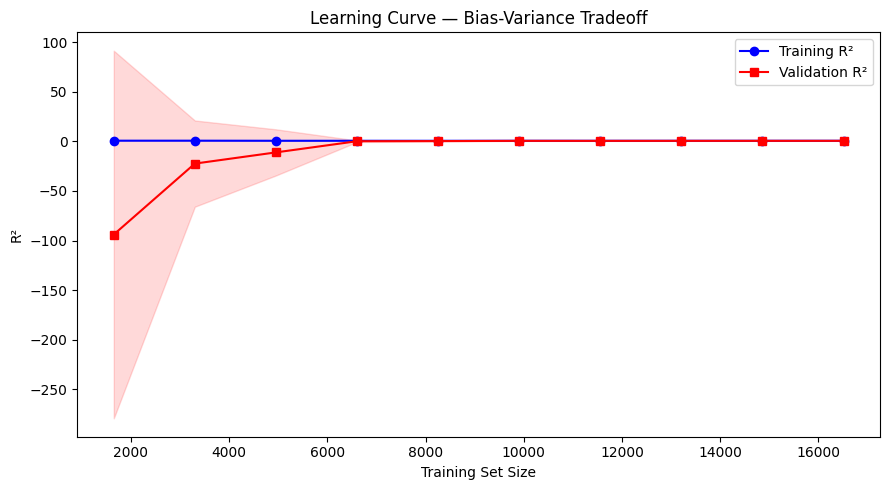

In [9]:
# ── Demonstrate with different training sizes ─────────────────────────────────
# WHY: Bias-variance tradeoff is easiest to see in a learning curve.
#      As training size grows, train score falls (less overfitting) while val score rises.

from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    pipe, X, y,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='r2',
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'bo-', label='Training R²')
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15, color='blue')
plt.plot(train_sizes, val_mean, 'rs-', label='Validation R²')
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.15, color='red')
plt.xlabel('Training Set Size')
plt.ylabel('R²')
plt.title('Learning Curve — Bias-Variance Tradeoff')
plt.legend()
plt.tight_layout()
plt.show()

## 📈 Step 5 — Residual Analysis

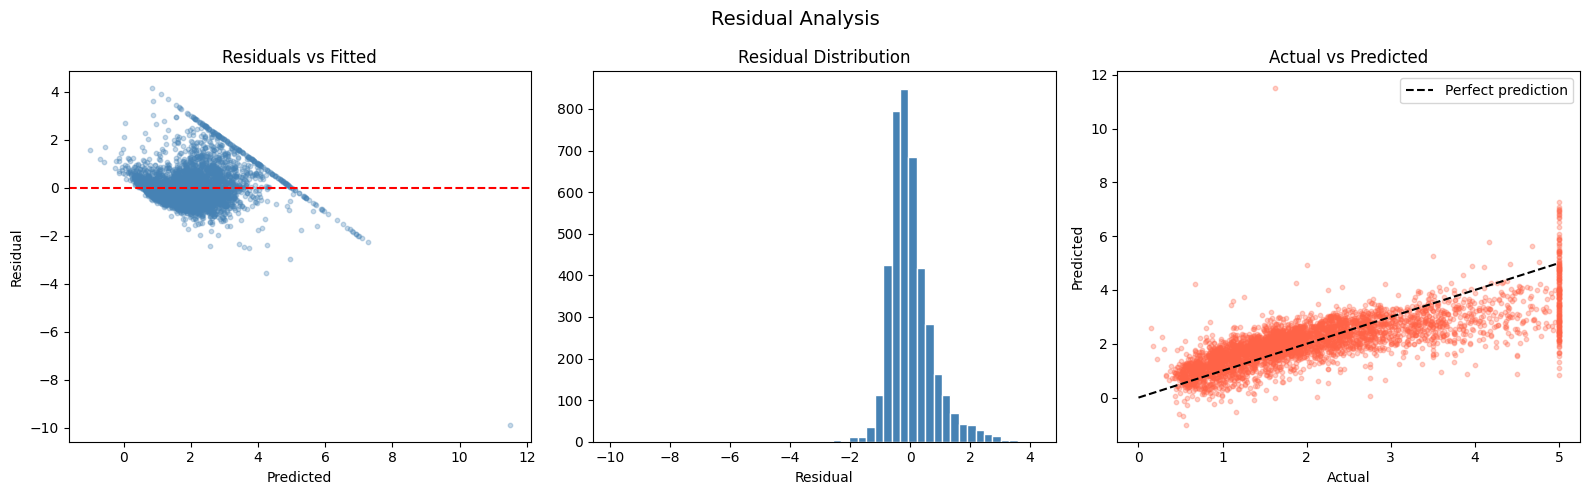

In [10]:
# ── Refit on full train split; residuals on test ──────────────────────────────
pipe.fit(X_train, y_train)
residuals = y_test - pipe.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Residual vs fitted
axes[0].scatter(pipe.predict(X_test), residuals, alpha=0.3, s=10, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Fitted')

# Residual histogram
axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')

# Actual vs Predicted
axes[2].scatter(y_test, pipe.predict(X_test), alpha=0.3, s=10, color='tomato')
lims = [min(y_test.min(), 0), y_test.max()]
axes[2].plot(lims, lims, 'k--', label='Perfect prediction')
axes[2].set_xlabel('Actual')
axes[2].set_ylabel('Predicted')
axes[2].set_title('Actual vs Predicted')
axes[2].legend()

plt.suptitle('Residual Analysis', fontsize=14)
plt.tight_layout()
plt.show()

## 📊 Step 6 — Feature Coefficients & Interpretation

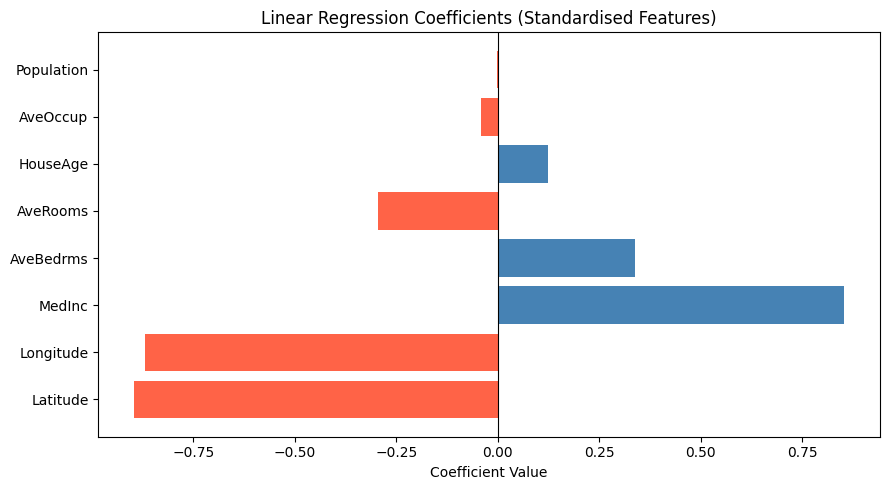


💡 Interpretation: Because features are standardised, coefficients are comparable.
   Larger absolute value = stronger influence on the prediction.


In [11]:
coef_df = pd.DataFrame({
    'Feature':     X.columns,
    'Coefficient': pipe.named_steps['lr'].coef_
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(9, 5))
colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Linear Regression Coefficients (Standardised Features)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

print('\n💡 Interpretation: Because features are standardised, coefficients are comparable.')
print('   Larger absolute value = stronger influence on the prediction.')

## 🎯 Summary

| Method | R² | Notes |
|---|---|---|
| Single 80/20 split | varies by seed | Unreliable estimate |
| 5-Fold CV (mean) | most reliable | Use this as official score |

### Key Takeaways:
1. **K-Fold** is the gold standard for model evaluation — always report mean ± std
2. **Pipelines** are mandatory with K-Fold to prevent leakage
3. **Residual plots** reveal violations of linear regression assumptions
4. **Standardised coefficients** allow fair feature importance comparison

---

**Next:** [05_linear_regression_from_scratch.ipynb](05_linear_regression_from_scratch.ipynb)